# Random Forest — avaliação sem data leakage

Este notebook treina um `RandomForestClassifier` com `data/prepared_landmarks.csv`. A avaliação usa **leave-one-participant-out**: a cada rodada, todos os frames de um participante são reservados para teste e o modelo é treinado exclusivamente com os outros participantes.

Proteções contra leakage:

- `label`, `participant_id`, `session_id` e `frame_index` nunca entram em `X`;
- nenhum participante ou sessão aparece simultaneamente no treino e no teste;
- as métricas são calculadas com previsões out-of-fold, feitas quando cada pessoa estava totalmente fora do treino;
- os hiperparâmetros são fixados antes da avaliação, sem ajuste sobre os participantes de teste;
- o modelo final é ajustado com todos os dados somente depois da avaliação.

Com apenas três participantes, as métricas ainda têm alta incerteza. O protocolo mede generalização para pessoas não vistas, mas deve ser repetido quando houver mais participantes.

In [20]:
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import LeaveOneGroupOut

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "trainings":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "prepared_landmarks.csv"
MODEL_PATH = PROJECT_ROOT / "model" / "random_forest.pkl"
METADATA_PATH = PROJECT_ROOT / "model" / "random_forest_metadata.joblib"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset preparado não encontrado: {DATA_PATH}")

DATA_PATH

WindowsPath('C:/Users/tamj4/Desktop/Projeto_ia/DinoGesture/data/prepared_landmarks.csv')

## 1. Carregamento e validação do dataset

O notebook espera 1.404 coordenadas (`x`, `y`, `z` para 468 landmarks) e 30 features derivadas pelo notebook de preparação.

In [21]:
metadata_columns = ["label", "participant_id", "session_id", "frame_index"]
coordinate_columns = [
    f"{axis}_{index}"
    for index in range(468)
    for axis in ("x", "y", "z")
]

header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
missing_columns = set(metadata_columns + coordinate_columns) - set(header)
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes: {sorted(missing_columns)}")

engineered_feature_columns = [
    column
    for column in header
    if column not in metadata_columns + coordinate_columns
]
if len(engineered_feature_columns) != 30:
    raise ValueError(
        f"Esperadas 30 features derivadas, recebidas {len(engineered_feature_columns)}. "
        "Execute novamente notebooks/data_prep.ipynb."
    )

dtypes = {column: "float32" for column in coordinate_columns + engineered_feature_columns}
dtypes.update({
    "label": "string",
    "participant_id": "int8",
    "session_id": "string",
    "frame_index": "int32",
})
df = pd.read_csv(DATA_PATH, dtype=dtypes)

if df.isna().any().any():
    raise ValueError("O dataset contém valores ausentes.")

numeric_columns = coordinate_columns + engineered_feature_columns
if not np.isfinite(df[numeric_columns].to_numpy(copy=False)).all():
    raise ValueError("O dataset contém valores numéricos não finitos.")

dataset_report = pd.Series({
    "amostras": len(df),
    "coordenadas": len(coordinate_columns),
    "features_derivadas": len(engineered_feature_columns),
    "participantes": df["participant_id"].nunique(),
    "sessões": df[["participant_id", "session_id"]].drop_duplicates().shape[0],
    "classes": df["label"].nunique(),
}, name="valor")
display(dataset_report.to_frame())
display(pd.crosstab(df["participant_id"], df["label"], margins=True))

,valor
amostras,7440
coordenadas,1404
features_derivadas,30
participantes,3
sessões,62
classes,3


label,boca_aberta,neutro,sobrancelha,All
participant_id,,,,
1,1200,1200,1200,3600
2,600,720,720,2040
3,600,600,600,1800
All,2400,2520,2520,7440


## 2. Matriz preditora e grupos

`participant_id` é usado exclusivamente para construir os folds. A chave de sessão é usada para uma segunda validação de isolamento.

In [22]:
feature_columns = coordinate_columns + engineered_feature_columns
X = df[feature_columns].copy()
y = df["label"].copy()
participant_groups = df["participant_id"].copy()
session_groups = (
    df["participant_id"].astype(str)
    + "::"
    + df["session_id"].astype(str)
)
labels = sorted(y.unique().tolist())

assert set(metadata_columns).isdisjoint(X.columns)
assert X.shape == (len(df), 1434)
assert participant_groups.nunique() == 3
assert set(labels) == {"boca_aberta", "neutro", "sobrancelha"}
assert df.groupby("participant_id")["label"].nunique().eq(len(labels)).all()

print(f"X: {X.shape} | y: {y.shape} | participantes: {participant_groups.nunique()}")

X: (7440, 1434) | y: (7440,) | participantes: 3


## 3. Configuração fixa do Random Forest

O Random Forest não precisa de `StandardScaler`. Usamos `class_weight='balanced_subsample'` para compensar diferenças entre classes e pesos amostrais para que cada participante contribua com o mesmo peso total no treino. Os hiperparâmetros não são escolhidos com base nos resultados abaixo.

In [23]:
MODEL_PARAMETERS = {
    "n_estimators": 400,
    "max_depth": None,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
    "random_state": 42,
    "n_jobs": -1,
}
base_model = RandomForestClassifier(**MODEL_PARAMETERS)

def participant_balanced_weights(groups):
    counts = groups.value_counts()
    participant_count = len(counts)
    target_total_per_participant = len(groups) / participant_count
    return (
        groups.map(target_total_per_participant / counts)
        .to_numpy(dtype=np.float32)
    )

base_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

## 4. Avaliação leave-one-participant-out

Cada previsão usada nas métricas é produzida por um modelo que nunca viu nenhum frame da pessoa avaliada. Como uma pessoa inteira fica fora, suas sessões também ficam automaticamente fora do treino.

In [24]:
splitter = LeaveOneGroupOut()
oof_predictions = np.full(len(df), None, dtype=object)
fold_metrics = []

for fold_number, (train_index, test_index) in enumerate(
    splitter.split(X, y, groups=participant_groups),
    start=1,
):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    train_participants = participant_groups.iloc[train_index]
    test_participants = participant_groups.iloc[test_index]
    train_sessions = session_groups.iloc[train_index]
    test_sessions = session_groups.iloc[test_index]

    assert set(train_participants).isdisjoint(set(test_participants))
    assert set(train_sessions).isdisjoint(set(test_sessions))
    assert y_train.nunique() == y_test.nunique() == len(labels)

    model = clone(base_model)
    model.fit(
        X_train,
        y_train,
        sample_weight=participant_balanced_weights(train_participants),
    )
    predictions = model.predict(X_test)
    oof_predictions[test_index] = predictions

    held_out_participant = int(test_participants.iloc[0])
    fold_metrics.append({
        "fold": fold_number,
        "participante_teste": held_out_participant,
        "amostras_teste": len(test_index),
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "f1_macro": f1_score(y_test, predictions, average="macro", zero_division=0),
    })
    print(
        f"Fold {fold_number}: participante {held_out_participant} no teste | "
        f"treino={len(train_index):,} | teste={len(test_index):,}"
    )

assert all(prediction is not None for prediction in oof_predictions)
fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
display(fold_metrics_df)

Fold 1: participante 1 no teste | treino=3,840 | teste=3,600
Fold 2: participante 2 no teste | treino=5,400 | teste=2,040
Fold 3: participante 3 no teste | treino=5,640 | teste=1,800


,participante_teste,amostras_teste,accuracy,balanced_accuracy,f1_macro
fold,,,,,
1,1,3600,0.9303,0.9303,0.9302
2,2,2040,0.9407,0.9432,0.9435
3,3,1800,0.9989,0.9989,0.9989


In [25]:
overall_metrics = {
    "accuracy": accuracy_score(y, oof_predictions),
    "balanced_accuracy": balanced_accuracy_score(y, oof_predictions),
    "f1_macro": f1_score(y, oof_predictions, average="macro", zero_division=0),
}
display(pd.Series(overall_metrics, name="OOF geral").to_frame())



,OOF geral
accuracy,0.9497
balanced_accuracy,0.9504
f1_macro,0.9505


In [26]:

report_df = pd.DataFrame(
    classification_report(
        y,
        oof_predictions,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
).T
report_df

,precision,recall,f1-score,support
boca_aberta,0.9992,0.9912,0.9952,2400.0000
neutro,0.9146,0.9437,0.9289,2520.0000
sobrancelha,0.9390,0.9163,0.9275,2520.0000
accuracy,0.9497,0.9497,0.9497,0.9497
macro avg,0.9509,0.9504,0.9505,7440.0000
weighted avg,0.9501,0.9497,0.9498,7440.0000


In [27]:

confusion_df = pd.DataFrame(
    confusion_matrix(y, oof_predictions, labels=labels),
    index=[f"real_{label}" for label in labels],
    columns=[f"previsto_{label}" for label in labels],
)
confusion_df

,previsto_boca_aberta,previsto_neutro,previsto_sobrancelha
real_boca_aberta,2379,13,8
real_neutro,0,2378,142
real_sobrancelha,2,209,2309


Avaliação geral do modelo (previsões OOF)

              precision    recall  f1-score   support

 boca_aberta       1.00      0.99      1.00      2400
      neutro       0.91      0.94      0.93      2520
 sobrancelha       0.94      0.92      0.93      2520

    accuracy                           0.95      7440
   macro avg       0.95      0.95      0.95      7440
weighted avg       0.95      0.95      0.95      7440



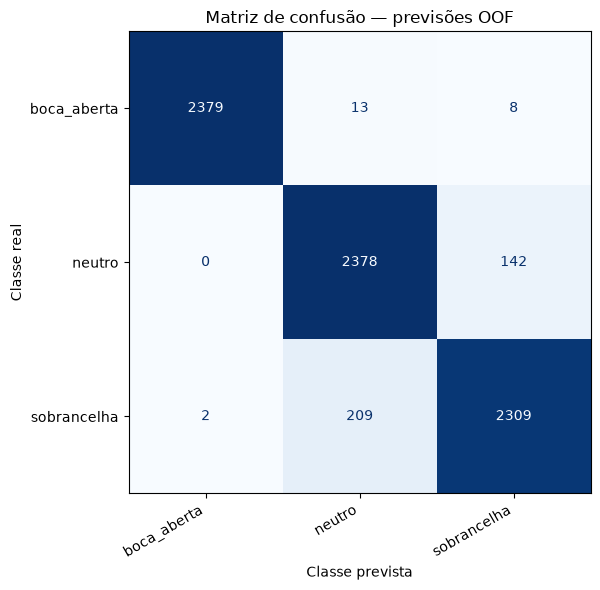

In [28]:


print("Avaliação geral do modelo (previsões OOF)\n")
print(
    classification_report(
        y,
        oof_predictions,
        labels=labels,
        target_names=[str(label) for label in labels],
        digits=2,
        zero_division=0,
    )
)

figure, axis = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=axis,
)
axis.set_title("Matriz de confusão — previsões OOF")
axis.set_xlabel("Classe prevista")
axis.set_ylabel("Classe real")
plt.setp(axis.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Treino final e persistência

Após a avaliação, ajustamos uma nova instância com os três participantes. Esse modelo final não é usado para recalcular as métricas. O classificador é salvo como objeto puro para manter compatibilidade com `model/Model.py`; a ordem das features, os parâmetros e as métricas são salvos separadamente.

In [29]:
final_model = clone(base_model)
final_model.fit(
    X,
    y,
    sample_weight=participant_balanced_weights(participant_groups),
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": final_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(30))

model_metadata = {
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_path": str(DATA_PATH),
    "evaluation_protocol": "LeaveOneGroupOut por participant_id",
    "feature_columns": feature_columns,
    "coordinate_columns": coordinate_columns,
    "engineered_feature_columns": engineered_feature_columns,
    "classes": final_model.classes_.tolist(),
    "model_parameters": MODEL_PARAMETERS,
    "oof_metrics": overall_metrics,
    "fold_metrics": fold_metrics_df.reset_index().to_dict(orient="records"),
    "top_feature_importance": feature_importance.head(100).to_dict(orient="records"),
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_PATH, compress=3)
joblib.dump(model_metadata, METADATA_PATH, compress=3)

print(f"Modelo salvo em: {MODEL_PATH}")
print(f"Metadados salvos em: {METADATA_PATH}")

,feature,importance
0,dist_media_sobrancelhas_olhos,0.0279
1,media_movel_5_sobrancelha_esquerda,0.0206
2,dist_sobrancelha_esquerda_olho_esquerdo,0.0202
3,dist_vertical_sobrancelha_esquerda_olho,0.0202
4,y_317,0.0197
5,media_movel_5_sobrancelha_direita,0.0197
6,dist_vertical_sobrancelha_direita_olho,0.0193
7,dist_vertical_media_sobrancelhas_olhos,0.0170
8,mouth_aspect_ratio,0.0161
9,area_abertura_boca,0.0159


Modelo salvo em: C:\Users\tamj4\Desktop\Projeto_ia\DinoGesture\model\random_forest.pkl
Metadados salvos em: C:\Users\tamj4\Desktop\Projeto_ia\DinoGesture\model\random_forest_metadata.joblib


## 6. Verificação do artefato salvo

Recarregamos o arquivo e confirmamos a quantidade e a ordem das features antes de encerrar.

In [30]:
loaded_model = joblib.load(MODEL_PATH)
loaded_metadata = joblib.load(METADATA_PATH)

assert loaded_model.n_features_in_ == X.shape[1]
assert loaded_model.feature_names_in_.tolist() == feature_columns
assert loaded_metadata["feature_columns"] == feature_columns
assert loaded_metadata["classes"] == sorted(y.unique().tolist())
assert np.isfinite(loaded_model.predict_proba(X.iloc[:10])).all()

artifact_report = pd.Series({
    "modelo_MB": MODEL_PATH.stat().st_size / 1024**2,
    "metadados_MB": METADATA_PATH.stat().st_size / 1024**2,
    "features": loaded_model.n_features_in_,
    "árvores": len(loaded_model.estimators_),
    "classes": len(loaded_model.classes_),
}, name="valor")
display(artifact_report.to_frame())

,valor
modelo_MB,0.8268
metadados_MB,0.0078
features,1434.0000
árvores,400.0000
classes,3.0000
